# Part 0: Expert Data Collection

In Habitat ObjectNav, expert demonstrations come from the **ShortestPathFollower** oracle.
Given the agent's current pose and the goal location, the oracle computes the shortest geodesic
path on the navigation mesh and returns the next discrete action at each timestep.

This section explores the 6-action discrete space, visualizes a typical expert action distribution,
and runs a quick discrete baseline training loop.

In [1]:
# ShortestPathFollower conceptual usage (habitat may not be installed):
#
# from habitat.tasks.nav.shortest_path_follower import ShortestPathFollower
# follower = ShortestPathFollower(sim, goal_radius=0.1, return_one_hot=False)
# action = follower.get_next_action(goal_position)
#
# The follower returns one of the HabitatAction enum values at each step.

import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.action_heads.discrete_head import HabitatAction

print("Action space:")
for a in HabitatAction:
    print(f"  {a.name} = {a.value}")

Action space:
  STOP = 0
  MOVE_FORWARD = 1
  TURN_LEFT = 2
  TURN_RIGHT = 3
  LOOK_UP = 4
  LOOK_DOWN = 5


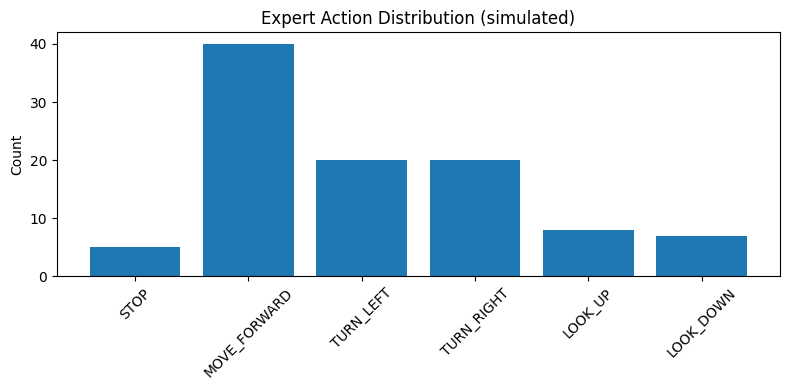

In [2]:
import torch
import matplotlib.pyplot as plt

# Simulated expert action distribution (typical ObjectNav)
actions = torch.tensor([1]*40 + [2]*20 + [3]*20 + [0]*5 + [4]*8 + [5]*7)

plt.figure(figsize=(8, 4))
plt.hist(actions.numpy(), bins=range(7), align='left', rwidth=0.8)
plt.xticks(range(6), [a.name for a in HabitatAction], rotation=45)
plt.title("Expert Action Distribution (simulated)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [3]:
from src.action_heads import DiscreteActionHead
import torch.nn.functional as F

head = DiscreteActionHead(cond_dim=32, hidden_dim=32)
opt = torch.optim.Adam(head.parameters(), lr=1e-3)

# Dummy: random cond -> random action labels
for i in range(100):
    cond = torch.randn(16, 32)
    labels = torch.randint(0, 6, (16,))
    loss = F.cross_entropy(head(cond), labels)
    opt.zero_grad(); loss.backward(); opt.step()

print(f"Final loss: {loss.item():.4f}")

Final loss: 1.8276


# Part 1: Diffusion Policy from Scratch

Build intuition for DDPM-based action generation:
1. Compare linear vs cosine noise schedules
2. Visualize forward diffusion on 2D Swiss Roll data
3. Train a tiny denoiser and sample from it

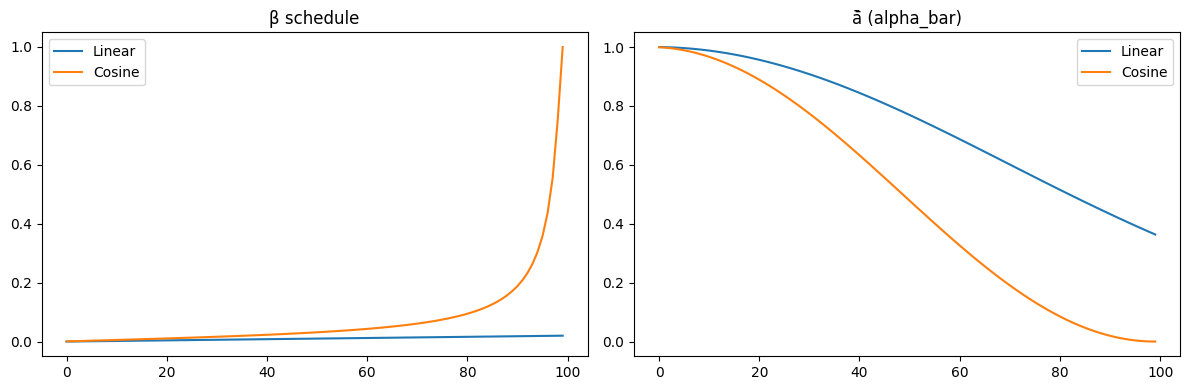

In [4]:
from src.action_heads.noise_schedules import linear_beta_schedule, cosine_beta_schedule, compute_alpha_bar

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, fn in [("Linear", linear_beta_schedule), ("Cosine", cosine_beta_schedule)]:
    betas = fn(100)
    alpha_bar = compute_alpha_bar(betas)
    axes[0].plot(betas.numpy(), label=name)
    axes[1].plot(alpha_bar.numpy(), label=name)
axes[0].set_title("\u03b2 schedule"); axes[0].legend()
axes[1].set_title("\u0101\u0304 (alpha_bar)"); axes[1].legend()
plt.tight_layout(); plt.show()

In [5]:
from sklearn.datasets import make_swiss_roll
import numpy as np

X, _ = make_swiss_roll(1000, noise=0.5)
X_2d = torch.tensor(X[:, [0, 2]], dtype=torch.float32)
X_2d = (X_2d - X_2d.mean(0)) / X_2d.std(0)

betas = cosine_beta_schedule(100)
alpha_bar = compute_alpha_bar(betas)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, t in enumerate([0, 25, 50, 75, 99]):
    ab = alpha_bar[t]
    noisy = ab.sqrt() * X_2d + (1 - ab).sqrt() * torch.randn_like(X_2d)
    axes[i].scatter(noisy[:, 0].numpy(), noisy[:, 1].numpy(), s=1, alpha=0.5)
    axes[i].set_title(f"t={t}, \u0101\u0304={ab:.3f}")
    axes[i].set_xlim(-4, 4); axes[i].set_ylim(-4, 4)
plt.suptitle("Forward Diffusion Process"); plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from src.action_heads.common import SinusoidalPosEmb
import torch.nn as nn

# Tiny 2D denoiser
class TinyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_emb = SinusoidalPosEmb(32)
        self.net = nn.Sequential(
            nn.Linear(2 + 32, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, 2),
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_emb(t)], dim=-1))

model = TinyDenoiser()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(300):
    idx = torch.randint(0, len(X_2d), (256,))
    x_0 = X_2d[idx]
    t = torch.randint(0, 100, (256,))
    noise = torch.randn_like(x_0)
    ab = alpha_bar[t].unsqueeze(-1)
    x_t = ab.sqrt() * x_0 + (1 - ab).sqrt() * noise
    loss = F.mse_loss(model(x_t, t.float()), noise)
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.4f}")

In [ ]:
@torch.no_grad()
def ddpm_sample_2d(model, n=1000, T=100):
    betas = cosine_beta_schedule(T)
    alphas = 1 - betas
    alpha_bar = compute_alpha_bar(betas)
    x = torch.randn(n, 2)
    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, dtype=torch.float32)
        eps = model(x, t_batch)
        x = (1/alphas[t].sqrt()) * (x - betas[t]/(1-alpha_bar[t]).sqrt() * eps)
        if t > 0:
            x += betas[t].sqrt() * torch.randn_like(x)
    return x

samples = ddpm_sample_2d(model)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_2d[:, 0].numpy(), X_2d[:, 1].numpy(), s=1, alpha=0.5)
axes[0].set_title("Original Swiss Roll")
axes[1].scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), s=1, alpha=0.5)
axes[1].set_title("DDPM Samples")
for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.tight_layout(); plt.show()

# Part 2: Flow Matching from Scratch

Flow matching learns a velocity field that transports noise to data along
straight optimal-transport paths. Compared to DDPM, training is simpler
(no noise schedule needed) and sampling uses an ODE solver with far fewer steps.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
x_0 = torch.randn(20, 2)  # noise
x_1 = X_2d[:20]  # data
for i in range(20):
    ts = torch.linspace(0, 1, 10)
    path = [(1-t)*x_0[i] + t*x_1[i] for t in ts]
    path = torch.stack(path)
    ax.plot(path[:, 0].numpy(), path[:, 1].numpy(), alpha=0.3, color='blue')
ax.scatter(x_0[:, 0].numpy(), x_0[:, 1].numpy(), c='red', s=30, label='x_0 (noise)')
ax.scatter(x_1[:, 0].numpy(), x_1[:, 1].numpy(), c='green', s=30, label='x_1 (data)')
ax.legend(); ax.set_title("Optimal Transport Paths"); plt.show()

In [ ]:
class TinyVelocity(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_emb = SinusoidalPosEmb(32)
        self.net = nn.Sequential(
            nn.Linear(2 + 32, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, 2),
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_emb(t)], dim=-1))

fm_model = TinyVelocity()
opt = torch.optim.Adam(fm_model.parameters(), lr=1e-3)

for epoch in range(300):
    idx = torch.randint(0, len(X_2d), (256,))
    x_1 = X_2d[idx]
    x_0 = torch.randn_like(x_1)
    t = torch.rand(256)
    x_t = (1 - t.unsqueeze(-1)) * x_0 + t.unsqueeze(-1) * x_1
    v_target = x_1 - x_0
    loss = F.mse_loss(fm_model(x_t, t), v_target)
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.4f}")

In [ ]:
@torch.no_grad()
def fm_sample_2d(model, n=1000, steps=20):
    dt = 1.0 / steps
    x = torch.randn(n, 2)
    for i in range(steps):
        t = torch.full((n,), i * dt)
        x = x + model(x, t) * dt
    return x

fm_samples = fm_sample_2d(fm_model)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_2d[:, 0].numpy(), X_2d[:, 1].numpy(), s=1, alpha=0.5)
axes[0].set_title("Original")
axes[1].scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), s=1, alpha=0.5)
axes[1].set_title("DDPM Samples")
axes[2].scatter(fm_samples[:, 0].numpy(), fm_samples[:, 1].numpy(), s=1, alpha=0.5)
axes[2].set_title("Flow Matching Samples")
for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.tight_layout(); plt.show()

# Part 3: Head-to-Head Comparison

Compare DDPM and Flow Matching on sample quality vs inference cost.
Flow Matching uses far fewer ODE steps — how does sample quality degrade
as we reduce the step count?

In [ ]:
import time

# Compare step counts at varying steps
fig, ax = plt.subplots(figsize=(8, 4))
for label, n_steps in [("Euler 5 steps", 5), ("Euler 10", 10), ("Euler 20", 20), ("Euler 50", 50)]:
    s = fm_sample_2d(fm_model, steps=n_steps)
    ax.scatter(s[:, 0].numpy(), s[:, 1].numpy(), s=1, alpha=0.3, label=label)
ax.legend(); ax.set_title("FM: Effect of ODE steps"); plt.show()

In [ ]:
import time

ddpm_times, fm_times = [], []
for _ in range(5):
    t0 = time.time(); ddpm_sample_2d(model, n=100, T=100); ddpm_times.append(time.time()-t0)
    t0 = time.time(); fm_sample_2d(fm_model, n=100, steps=20); fm_times.append(time.time()-t0)

print(f"DDPM (100 steps): {np.mean(ddpm_times)*1000:.1f}ms")
print(f"FM   (20 steps):  {np.mean(fm_times)*1000:.1f}ms")

# Part 4: FusionModule Integration

The `FusionModule` combines VGGT geometry outputs (world points, depth, relevance)
with camera pose and a CLIP goal embedding into a single conditioning vector.
This conditioning vector drives both the DDPM and Flow Matching action heads.

Here we test the full pipeline with dummy VGGT-shaped tensors and run a simple
ablation to see which input features affect the conditioning most.

In [ ]:
from src.action_heads import FusionModule, DDPMActionHead, FlowMatchingActionHead

fusion = FusionModule(cond_dim=64)
ddpm = DDPMActionHead(action_dim=4, cond_dim=64, chunk_size=4, n_steps=20, hidden_dim=64, n_layers=2)
fm = FlowMatchingActionHead(action_dim=4, cond_dim=64, chunk_size=4, hidden_dim=64, n_layers=2)

# Dummy VGGT outputs
B = 2
world_points = torch.randn(B, 3, 64, 64)
depth = torch.randn(B, 1, 64, 64)
relevance = torch.randn(B, 1, 64, 64)
pose = torch.randn(B, 9)
goal = torch.randn(B, 768)

cond = fusion(world_points, depth, relevance, pose, goal)
print(f"Conditioning shape: {cond.shape}")

ddpm_actions = ddpm.sample(cond)
fm_actions = fm.sample(cond, n_steps=10)
print(f"DDPM actions: {ddpm_actions.shape}")
print(f"FM actions: {fm_actions.shape}")

In [ ]:
# Ablation: remove relevance (zero it out)
cond_no_rel = fusion(world_points, depth, torch.zeros_like(relevance), pose, goal)
# Ablation: remove goal (zero it out)
cond_no_goal = fusion(world_points, depth, relevance, pose, torch.zeros_like(goal))

print(f"Cond diff (no relevance): {(cond - cond_no_rel).abs().mean():.4f}")
print(f"Cond diff (no goal): {(cond - cond_no_goal).abs().mean():.4f}")
print("Larger diff = feature matters more for conditioning")